# Universidad de Buenos Aires

# Aprendizaje Profundo - TP2

# Cohorte 24 - 2do bimestre 2026


El segundo TP comienza la semana de la clase 4 y la ventana de entrega estará abierta hasta las **23:59 hs del viernes 5 de junio (hora de Argentina)**. La resolución del TP es **individual**. Pueden utilizar tanto los contenidos vistos en clase, como otra bibliografía externa. Si se toman ideas de fuentes externas deben ser correctamente citadas incluyendo el correspondiente link o página de libro.

ESTE TP2 EQUIVALE A UN TERCIO DE SU NOTA FINAL.

El formato de entrega debe ser un link a un notebook de google colab. Importante permitir acceso a gvilcamiza.ext@fi.uba.ar y **habilitar los comentarios, para poder darles el feedback**. Si no lo hacen así no se podrá dar el feedback respectivo por cada pregunta.

El envío **se realizará en el siguiente link de google forms: [link](https://forms.gle/6yGAsYUywfSshnik9)**. Tanto los resultados, gráficas, como el código y las explicaciones deben quedar guardados y visualizables en el colab.

**NO SE VALIDARÁN ENVÍOS POR CORREO, EL MÉTODO DE ENTREGA ES SOLO POR EL FORMS.**

**Consideraciones a tener en cuenta:**

- Se entregará 1 solo colab para este TP2.
- Renombrar el archivo de la siguiente manera: **APELLIDO-NOMBRE-DL-TP2-Co24.ipynb**
- Los códigos deben poder ejecutarse.
- **IMPORTANTE:** Los resultados, cómo el código, los gráficos, los prints y las explicaciones deben quedar guardados y visualizables en el mismo notebook.
- **Prestar mucha atención a cada consigna, responder las preguntas justo debajo del enunciado que corresponda.**
- Solo se revisarán los trabajos que hayan sido enviados por el forms.


# CASO: Adult Census Income


El objetivo del trabajo es construir un modelo de clasificación binaria que, a partir de los datos censales de diferentes hogares, determine si un individuo pertenece al grupo de mayores o de menores ingresos. Para ello, se empleará un conjunto de variables demográficas, laborales y socioeconómicas que describen las características de cada persona. El estudio debe incluir el análisis exploratorio del dataset, la selección y justificación de las transformaciones más adecuadas para cada variable, la construcción de modelos basados tanto en técnicas de codificación tradicionales como también en representaciones avanzadas mediante embeddings, y la comparación final del desempeño obtenido por cada enfoque.

**Para este caso de estudio, consideraremos como variable de alta cardinalidad a las que tengan 10 o más valores únicos.**


**Encontrarán el dataset en el siguiente enlace de drive: [link](https://drive.google.com/drive/folders/1S-usUXkJP6OdzUS0zdC5CW-XqegiXzln?usp=sharing)**

Está compuesto por los siguientes features:

- **age**: Edad del individuo expresada en años.

- **workclass**: Tipo de empleador o relación laboral del individuo. Describe si trabaja en el sector privado, gobierno estatal, local, federal, por cuenta propia, sin remuneración, etc.

- **education**: Nivel educativo alcanzado. Incluye categorías como secundaria completada, licenciatura, maestría, doctorado, etc.

- **marital-status**: Estado civil (casado, nunca casado, divorciado, viudo, etc.).

- **occupation**: Tipo de ocupación o área laboral, donde se incluye ventas, servicios de protección, técnicos, gerencia ejecutiva, fuerzas armadas, etc.

- **relationship**: Relación del individuo con el jefe del hogar como esposo, esposa, hijo propio, pariente, no familiar, etc.

- **race**: Autoidentificación racial como blanca, negra, indígena, asiática, isleños del Pacífico, entre otras.

- **sex**: Sexo biológico del individuo (masculino o femenino).

- **capital-gain**: Ingresos obtenidos por ganancia de capital (por ejemplo, venta de acciones o propiedades).

- **capital-loss**: Pérdidas declaradas por capital.

- **hours-per-week**: Cantidad de horas trabajadas por semana.

- **skill-profile**: Habilidad principal o conocmiento técnico adquirido que podría aplicar en el trabajo.

- **native-country**: País de nacimiento del individuo. Incluye Estados Unidos y una lista amplia de países del mundo.

- **income (target)**: Clasificación binaria que indica si el ingreso anual del individuo es menor o igual a 50K o mayor a 50K.


## a) Análisis exploratorio de los datasets (2 puntos)

- Realizar un EDA apoyado en gráficas adecuadas y coherentes para el caso de estudio.
- Analizar detalladamente los valores únicos de cada variable categórica e identificar su nivel de cardinalidad.
- Justificar de manera detallada el tipo de transformación que se le asignará a cada variable, en especial a las categóricas. **Dependiendo de su cardinalidad, su contexto y/o lógica interna de orden**, podrán transformarse mediante label/ordinal encoding, one-hot encoding o mediante una capa de embeddings dentro del modelo.
- No es necesario aplicar la misma transformación para todas las variables categóricas. El dataset puede (y debe) incluir diferentes tipos de transformaciones según las características de cada variable.
- Redactar explícitamente la decisión final adoptada para cada variable y su justificación correspondiente.


# EDA


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df_train = pd.read_csv("./datasets/adult_train.csv")
df_val = pd.read_csv("./datasets/adult_val.csv")
print("Shape train", df_train.shape)
print("Shape val", df_val.shape)

Shape train (30162, 14)
Shape val (15060, 14)


In [3]:
resumen_train = pd.DataFrame(
    {
        "dtype": df_train.dtypes,
        "n_unicos": df_train.nunique(),
        "n_nulos": df_train.isnull().sum(),
        "pct_nulos": (df_train.isnull().mean() * 100).round(2),
    }
)
resumen_train

,dtype,n_unicos,n_nulos,pct_nulos
age,int64,72,0,0.0
workclass,str,7,0,0.0
education,str,16,0,0.0
marital-status,str,7,0,0.0
occupation,str,14,0,0.0
relationship,str,6,0,0.0
race,str,5,0,0.0
sex,str,2,0,0.0
capital-gain,int64,118,0,0.0
capital-loss,int64,90,0,0.0


In [4]:
resumen_val = pd.DataFrame(
    {
        "dtype": df_val.dtypes,
        "n_unicos": df_val.nunique(),
        "n_nulos": df_val.isnull().sum(),
        "pct_nulos": (df_val.isnull().mean() * 100).round(2),
    }
)
resumen_val

,dtype,n_unicos,n_nulos,pct_nulos
age,int64,73,0,0.0
workclass,str,7,0,0.0
education,str,16,0,0.0
marital-status,str,7,0,0.0
occupation,str,14,0,0.0
relationship,str,6,0,0.0
race,str,5,0,0.0
sex,str,2,0,0.0
capital-gain,int64,110,0,0.0
capital-loss,int64,79,0,0.0


Con estos resumenes podemos ver lo siguiente:

- No tenemos nulos en ninguna feature, pero una simple inspeccion visual del dataset revela que hay bastantes 0s en `capital-gain` y `capital-loss`
- Tenemos una cardinalidad bastante elevada en algunas features, por ejemplo `skill-profile` tiene 80 valores distintos. `native-country` tiene 40 valores distintos. Mientras que otras columnas muestran una cardinalidad elevada pero las más fuertes son las mencionadas anteriormente.
- Los datasets son consistentes en el aspecto que las features tienen la misma cardinalidad con la excepción de `native-country` que cuenta con 41 valores únicos en train y 40 en val.


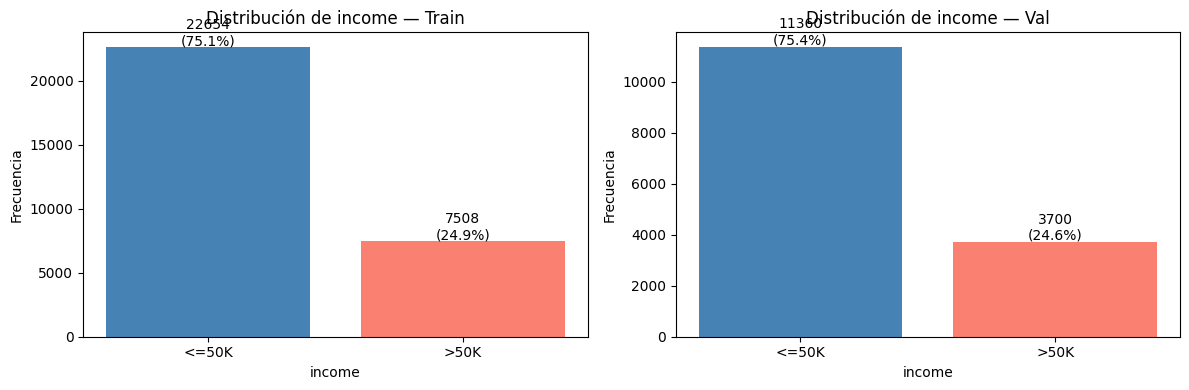

In [5]:
# Distribución del target en train y val
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (df, name) in zip(axes, [(df_train, "Train"), (df_val, "Val")]):
    counts = df["income"].value_counts()
    ax.bar(counts.index, counts.values, color=["steelblue", "salmon"])
    for i, v in enumerate(counts.values):
        ax.text(i, v + 100, f"{v}\n({v/len(df)*100:.1f}%)", ha="center")
    ax.set_title(f"Distribución de income — {name}")
    ax.set_xlabel("income")
    ax.set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()

/var/folders/6s/4bx8ks3n3l1305xxnc7lf9qh0000gn/T/ipykernel_95154/776743945.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot(groups, labels=["<=50K", ">50K"])
/var/folders/6s/4bx8ks3n3l1305xxnc7lf9qh0000gn/T/ipykernel_95154/776743945.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot(groups, labels=["<=50K", ">50K"])
/var/folders/6s/4bx8ks3n3l1305xxnc7lf9qh0000gn/T/ipykernel_95154/776743945.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, i].boxplot(groups, labels=["<=50K", ">50K"])
/var/folders/6s/4bx8ks3n3l1305xxnc7lf9qh0000gn/T/ipykernel_95154/776743945.py:10: 

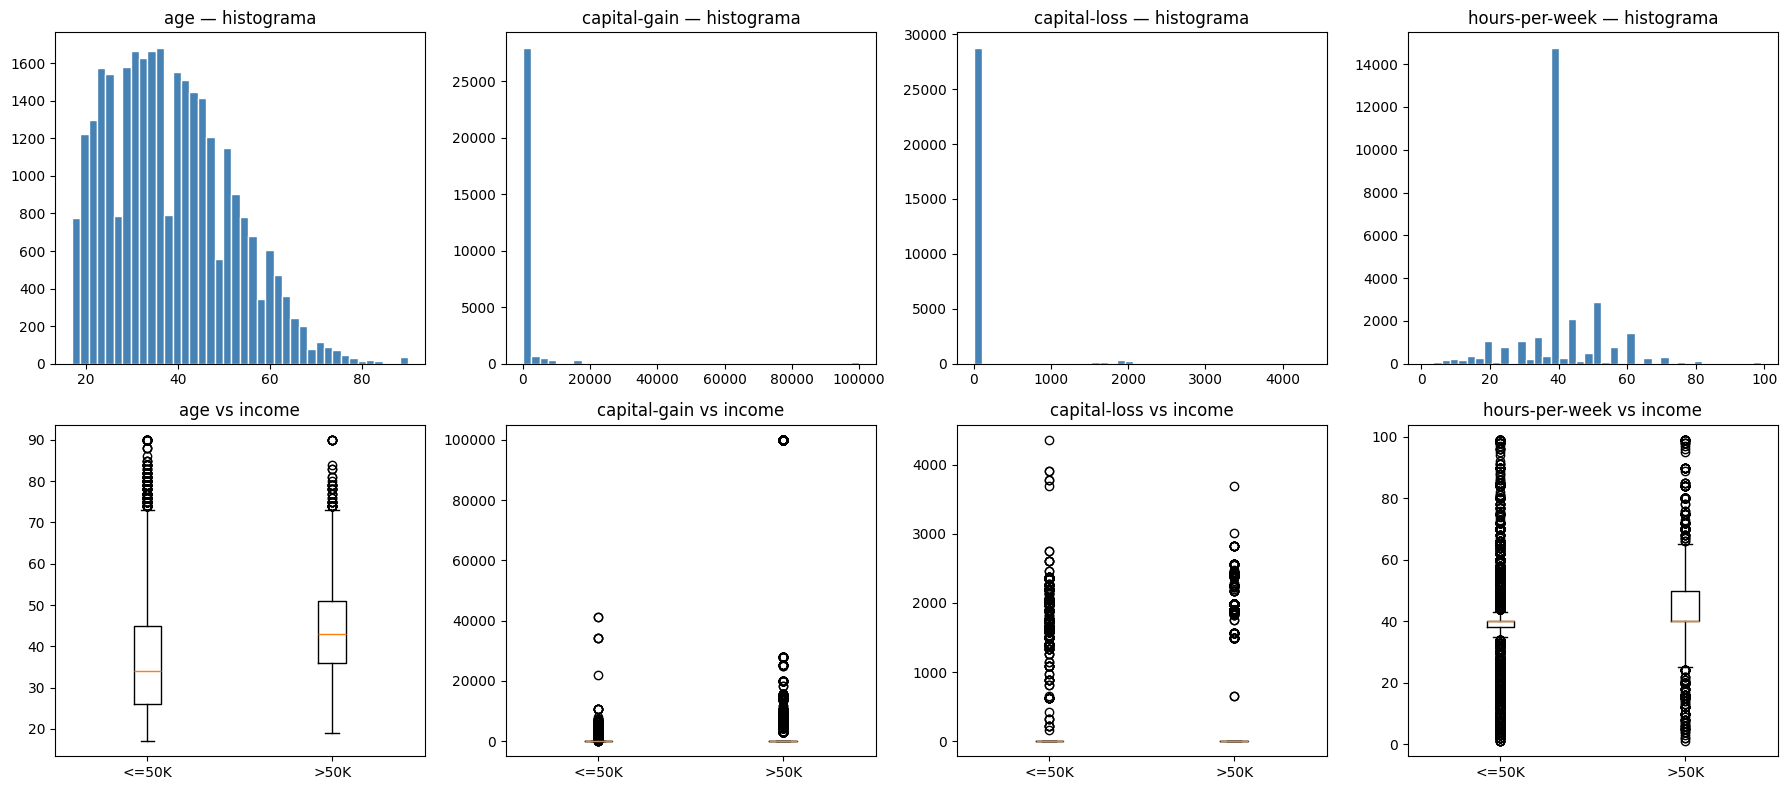

,age,capital-gain,capital-loss,hours-per-week
count,30162.000000,30162.000000,30162.000000,30162.000000
mean,38.437902,1092.007858,88.372489,40.931238
std,13.134665,7406.346497,404.298370,11.979984
min,17.000000,0.000000,0.000000,1.000000
25%,28.000000,0.000000,0.000000,40.000000
50%,37.000000,0.000000,0.000000,40.000000
75%,47.000000,0.000000,0.000000,45.000000
max,90.000000,99999.000000,4356.000000,99.000000


In [6]:
num_cols = ["age", "capital-gain", "capital-loss", "hours-per-week"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for i, col in enumerate(num_cols):
    # Histogram
    axes[0, i].hist(df_train[col], bins=40, color="steelblue", edgecolor="white")
    axes[0, i].set_title(f"{col} — histograma")
    # Box plot by target
    groups = [df_train[df_train["income"] == cat][col] for cat in ["<=50K", ">50K"]]
    axes[1, i].boxplot(groups, labels=["<=50K", ">50K"])
    axes[1, i].set_title(f"{col} vs income")
plt.tight_layout()
plt.show()

df_train[num_cols].describe()

/var/folders/6s/4bx8ks3n3l1305xxnc7lf9qh0000gn/T/ipykernel_95154/4130438206.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vc.index, rotation=45, ha="right")


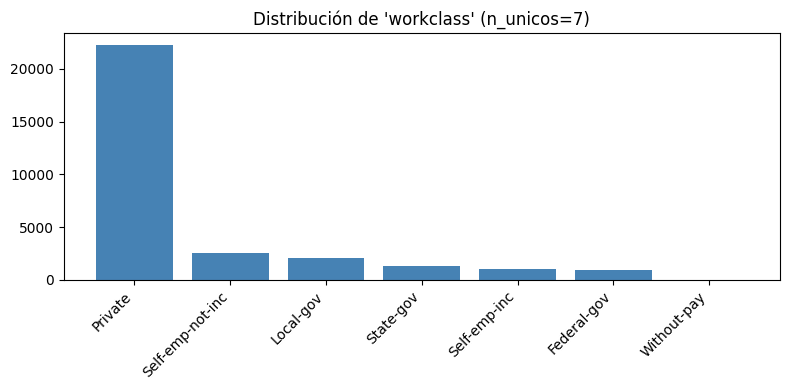

/var/folders/6s/4bx8ks3n3l1305xxnc7lf9qh0000gn/T/ipykernel_95154/4130438206.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vc.index, rotation=45, ha="right")


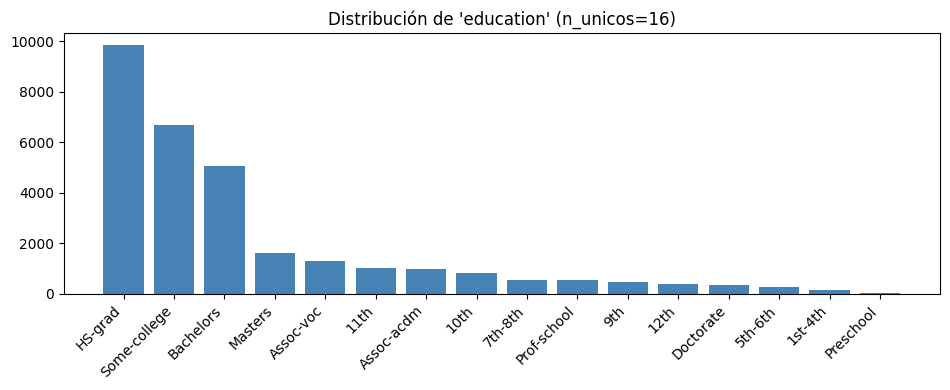

/var/folders/6s/4bx8ks3n3l1305xxnc7lf9qh0000gn/T/ipykernel_95154/4130438206.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vc.index, rotation=45, ha="right")


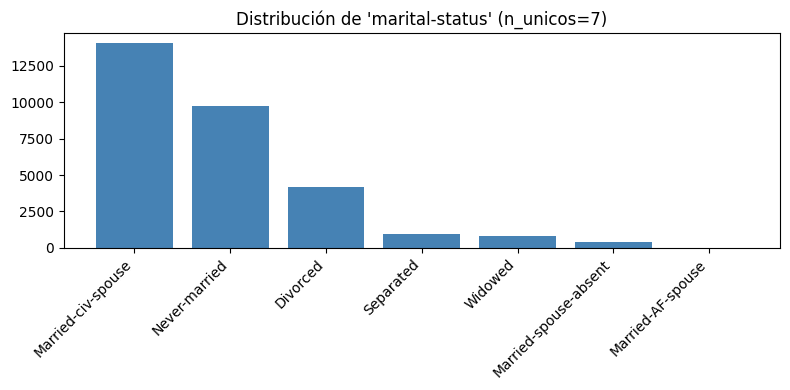

/var/folders/6s/4bx8ks3n3l1305xxnc7lf9qh0000gn/T/ipykernel_95154/4130438206.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vc.index, rotation=45, ha="right")


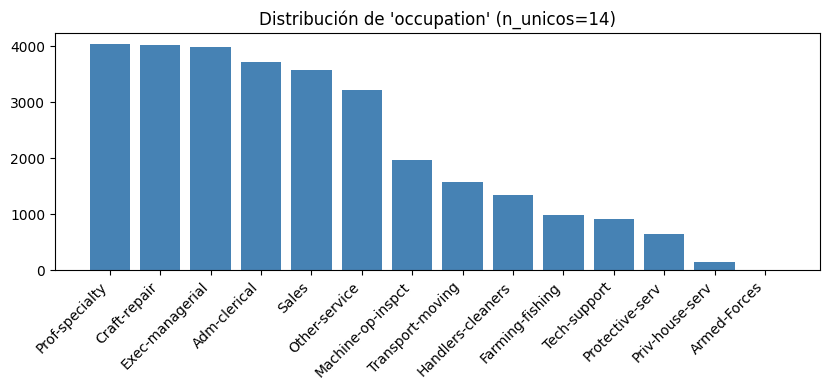

/var/folders/6s/4bx8ks3n3l1305xxnc7lf9qh0000gn/T/ipykernel_95154/4130438206.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vc.index, rotation=45, ha="right")


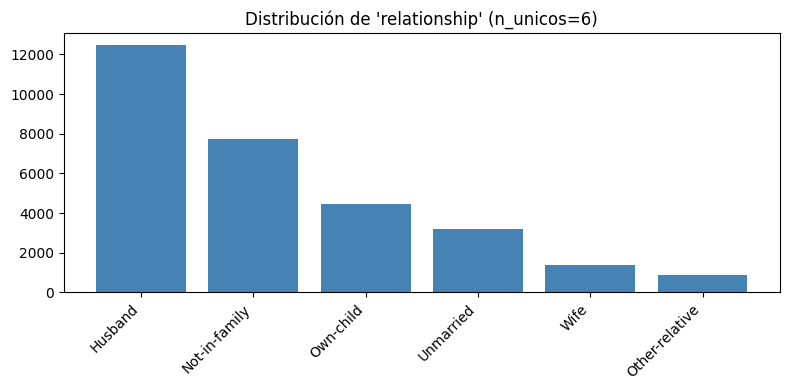

/var/folders/6s/4bx8ks3n3l1305xxnc7lf9qh0000gn/T/ipykernel_95154/4130438206.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vc.index, rotation=45, ha="right")


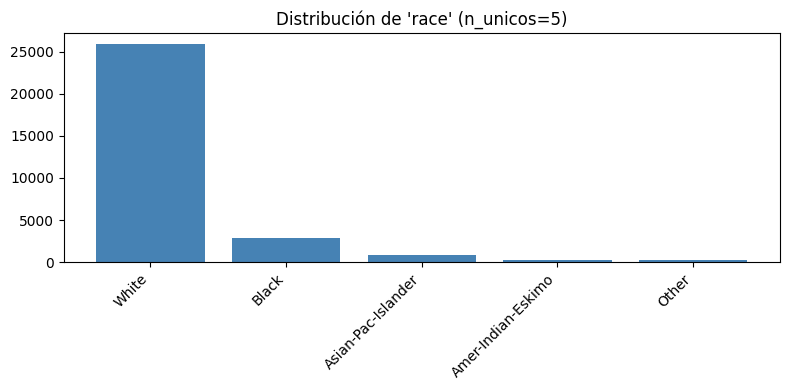

/var/folders/6s/4bx8ks3n3l1305xxnc7lf9qh0000gn/T/ipykernel_95154/4130438206.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vc.index, rotation=45, ha="right")


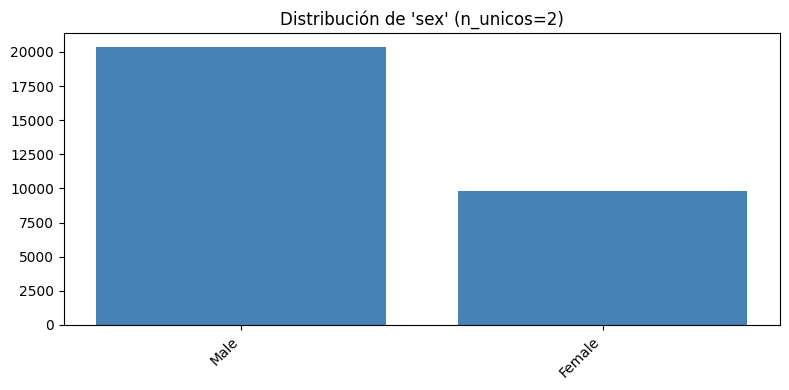

/var/folders/6s/4bx8ks3n3l1305xxnc7lf9qh0000gn/T/ipykernel_95154/4130438206.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vc.index, rotation=45, ha="right")


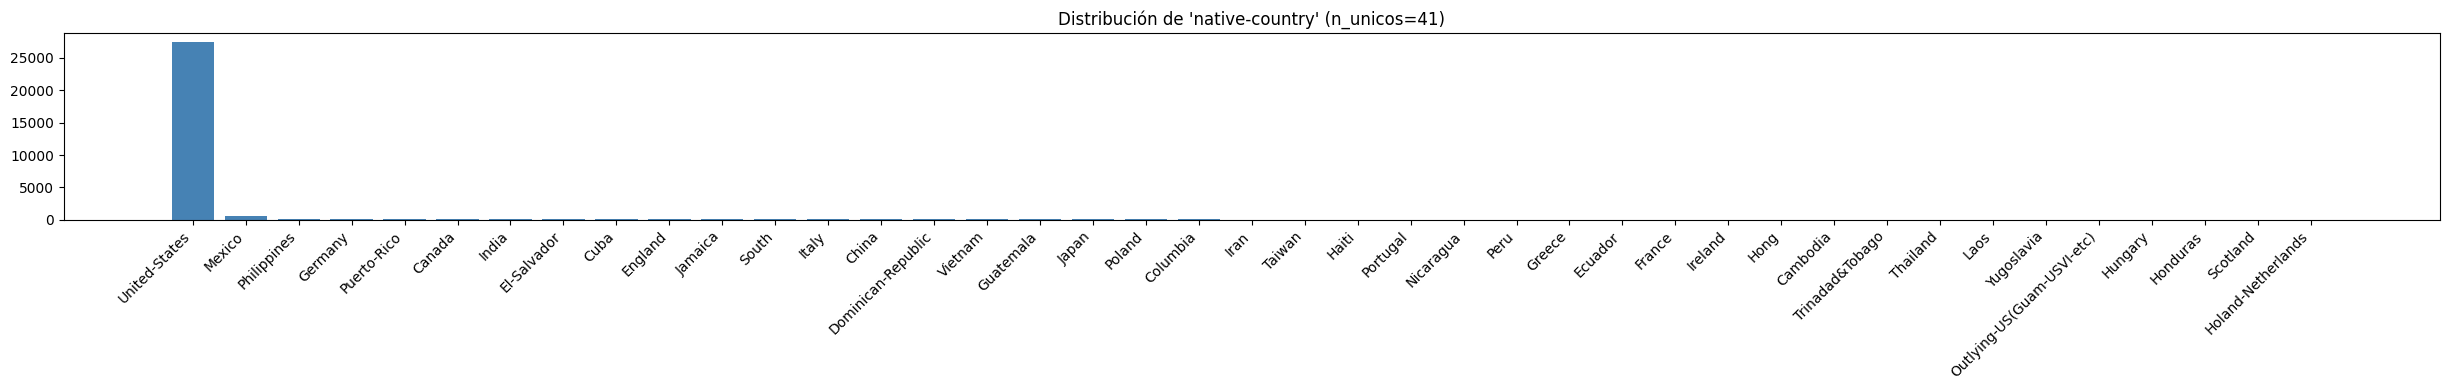

/var/folders/6s/4bx8ks3n3l1305xxnc7lf9qh0000gn/T/ipykernel_95154/4130438206.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(vc.index, rotation=45, ha="right")


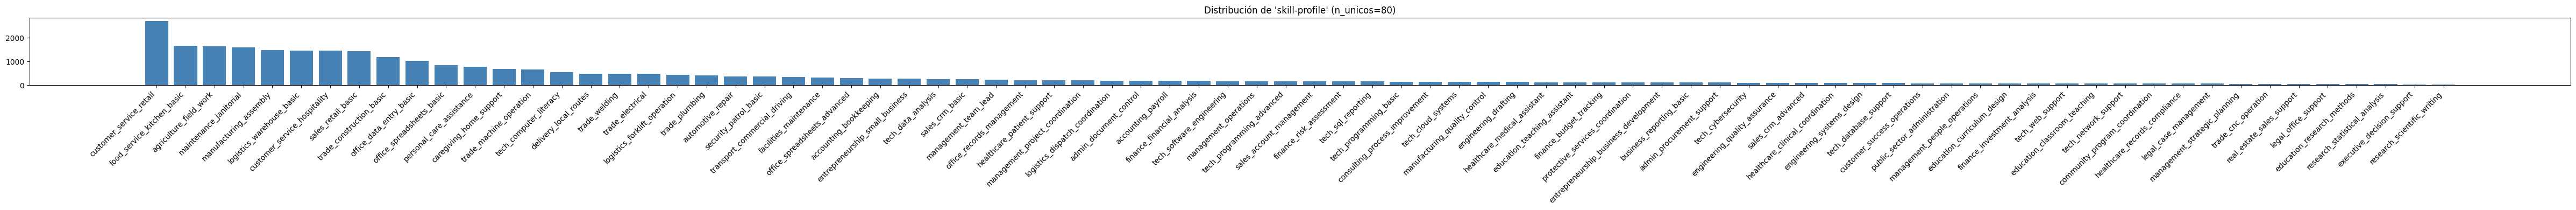

In [7]:
cat_cols = [
    "workclass",
    "education",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native-country",
    "skill-profile",
]

for col in cat_cols:
    vc = df_train[col].value_counts()
    fig, ax = plt.subplots(figsize=(max(8, len(vc) * 0.6), 4))
    ax.bar(vc.index, vc.values, color="steelblue")
    ax.set_title(f"Distribución de '{col}' (n_unicos={len(vc)})")
    ax.set_xticklabels(vc.index, rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

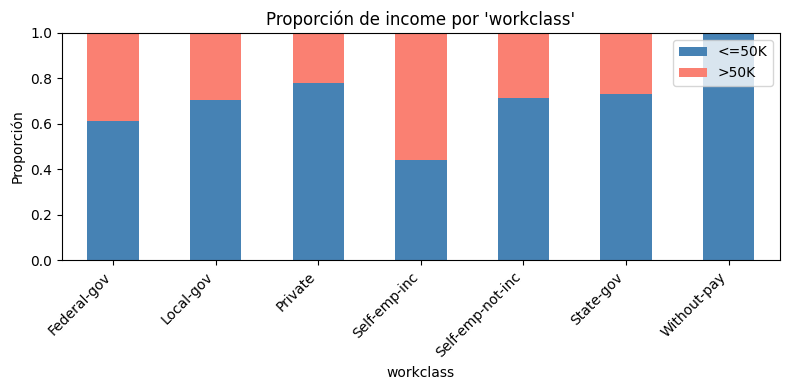

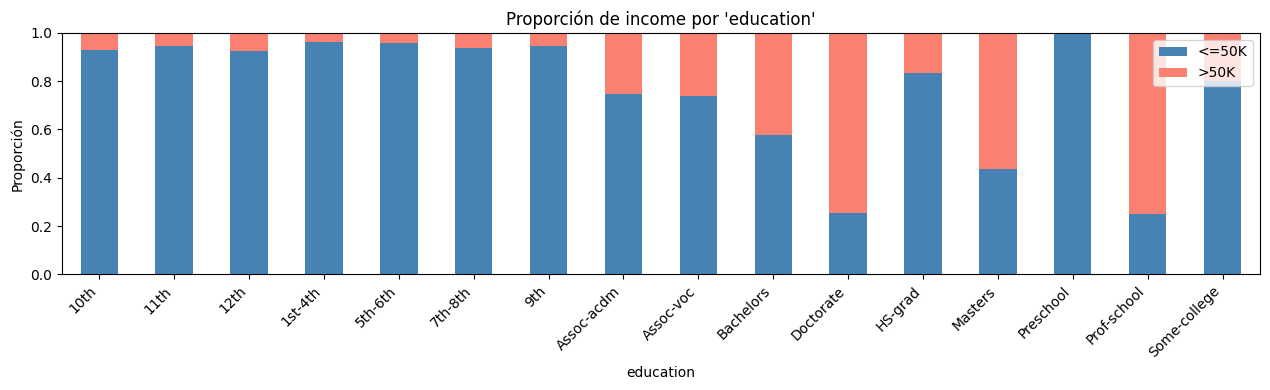

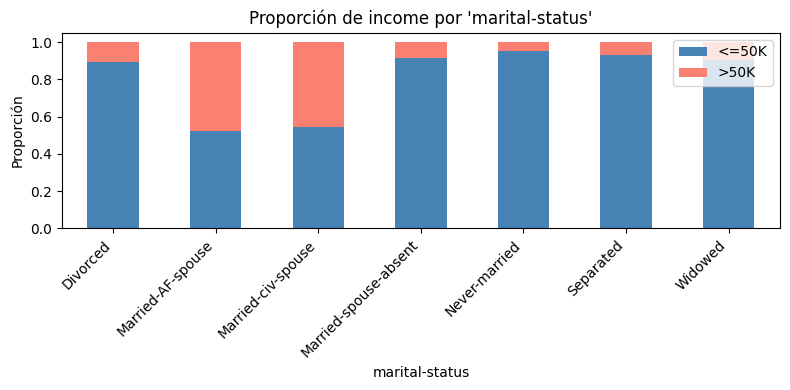

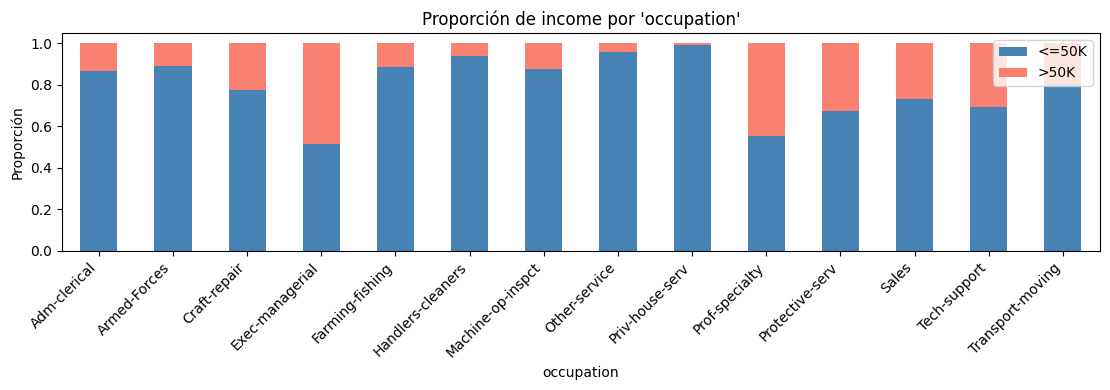

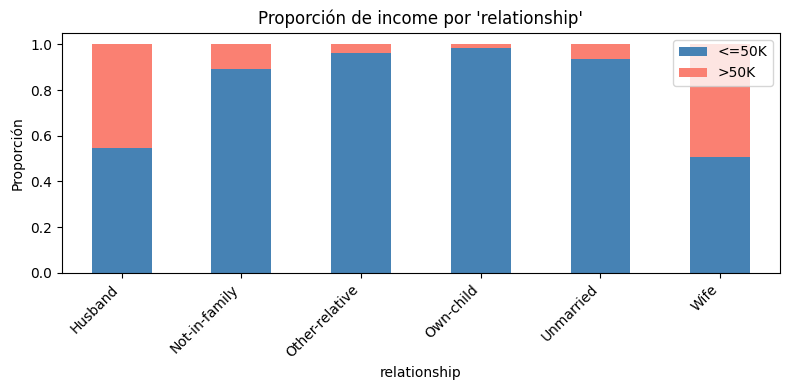

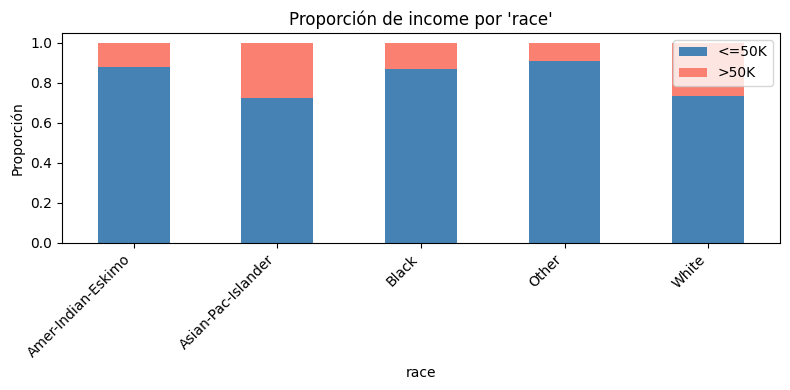

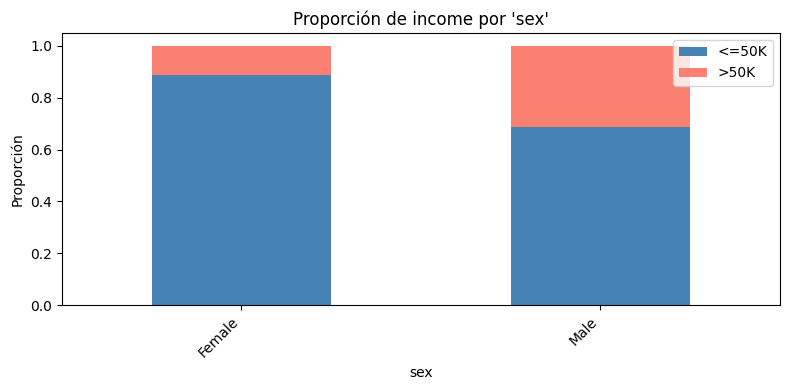

In [8]:
# Stacked bar: proportion of >50K per category
low_card_cols = [
    "workclass",
    "education",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
]

for col in low_card_cols:
    ct = pd.crosstab(df_train[col], df_train["income"], normalize="index")
    ct.plot(
        kind="bar",
        stacked=True,
        figsize=(max(8, len(ct) * 0.8), 4),
        color=["steelblue", "salmon"],
    )
    plt.title(f"Proporción de income por '{col}'")
    plt.ylabel("Proporción")
    plt.xticks(rotation=45, ha="right")
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

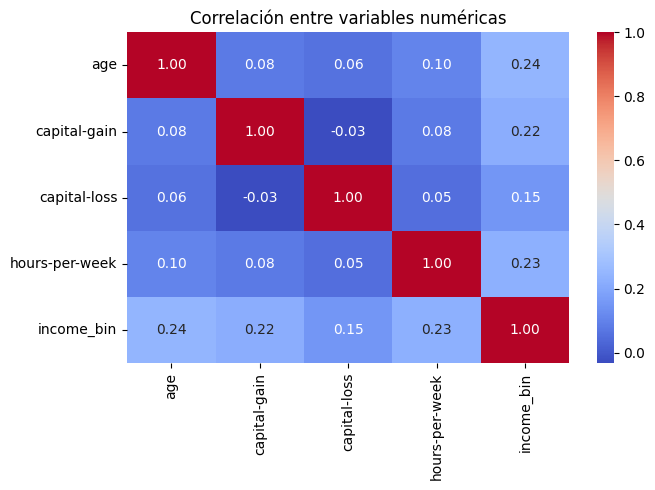

In [10]:
import seaborn as sns

corr = df_train[num_cols + ["income"]].copy()
corr["income_bin"] = (corr["income"] == ">50K").astype(int)
corr = corr.drop(columns="income")

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr.corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("Correlación entre variables numéricas")
plt.tight_layout()
plt.show()

capital-gain: 27624 ceros (91.6%)


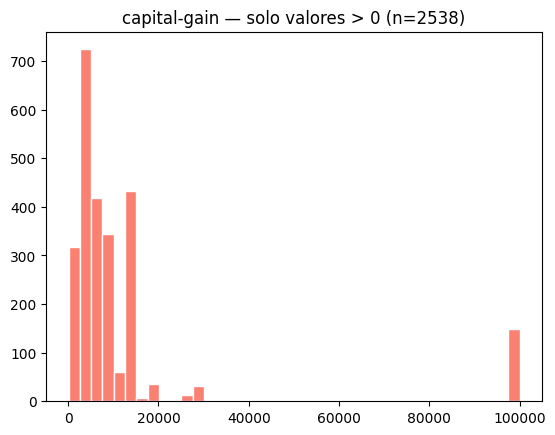

capital-loss: 28735 ceros (95.3%)


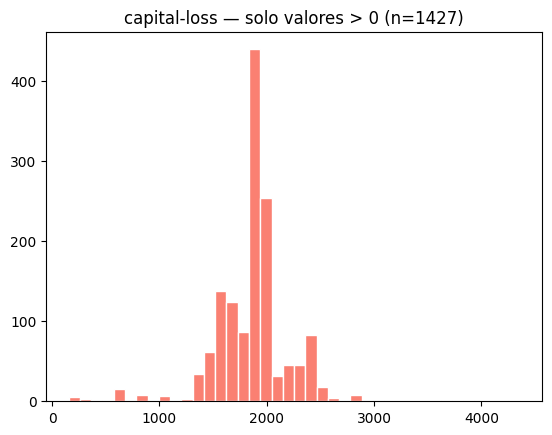

In [11]:
for col in ["capital-gain", "capital-loss"]:
    zeros = (df_train[col] == 0).sum()
    pct = zeros / len(df_train) * 100
    print(f"{col}: {zeros} ceros ({pct:.1f}%)")
    nonzero = df_train[df_train[col] > 0][col]
    plt.hist(nonzero, bins=40, color="salmon", edgecolor="white")
    plt.title(f"{col} — solo valores > 0 (n={len(nonzero)})")
    plt.show()

## b) Diseño y entrenamiento de un modelo con embeddings (3 puntos)

- Implementar las transformaciones definidas en el punto anterior e incorporarlas al flujo de entrenamiento.
- El modelo debe incluir, como mínimo, una capa de embedding para representar alguna de las variables categóricas.
- La elección de la dimensión del o los embeddings queda a criterio del estudiante, pero debe estar correctamente fundamentada. Recuerden que no es obligatorio que todos los embeddings tengan la misma dimensión.
- La configuración arquitectónica (número de capas, neuronas por capa, función de activación) es de libre elección.
- Incluir dropout en las capas ocultas de la red.
- Utilizar Adam o alguna de sus variantes como optimizador.
- Seleccionar la función de costo apropiada entre Binary CrossEntropyLoss o Categorical CrossEntropyLoss, según la formulación del problema.
- Mostrar las curvas de accuracy vs epoch y F1 macro vs epoch para los sets de entrenamiento y validación.
- Presentar un classification report generado con sklearn.
- Presentar una matriz de confusión absoluta y otra normalizada por fila, correspondientes al set de validación, con una paleta de colores entendible.


## c) Diseño y entrenamiento de un modelo sin embeddings (3 puntos)

- Entrenar un segundo modelo, aplicando one-hot encoding a todas las variables que en el punto b) fueron representadas mediante embeddings.
- Quitar todas las capas de dropout, para este segundo modelo no se usará ninguna capa interna de regularización.
- Con respecto al resto de capas, se debe mantener exactamente la misma arquitectura del modelo anterior: igual número de capas, misma cantidad de neuronas por capa y mismas funciones de activación.
- Presentar las mismas métricas, visualizaciones y reportes que en el modelo con embeddings.


## d) Conclusiones finales (2 puntos)

- Elaborar una tabla comparativa con los resultados obtenidos por ambos modelos. No solo comparar métricas de precisión, sino también la cantidad final de parámetros y entradas.
- Redactar detalladamente sus observaciones y apreciaciones derivadas de la comparación y plantear conclusiones fundamentadas respecto al desempeño de cada enfoque, justificando por qué uno funciona mejor o peor según las características del problema.
